In [2]:
import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.dates as mdates
import seaborn as sns
import tensorflow as tf
import tensorflow.keras.layers as kl
from tensorflow.keras.models    import Model, Sequential, load_model
from tensorflow.keras.layers    import Input, Conv1D, LSTM, Dense, Flatten, Dropout
from tensorflow.keras.layers    import Attention as KerasAttention
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.losses    import MeanSquaredError
from tensorflow.keras.metrics   import MeanAbsoluteError
from sklearn.preprocessing      import StandardScaler
from sklearn.metrics            import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble           import RandomForestRegressor
import xgboost as xgb

In [3]:

# ============================================================
# CHARGEMENT ET NETTOYAGE
# ============================================================

data = pd.read_csv("dataset_analytique_smarthsave_v2.csv", sep=",")
data['user_id']        = data['user_id'].astype(object)
data['institution_id'] = data['institution_id'].astype(object)
data['categorie_id']   = data['categorie_id'].astype(object)


# ============================================================
# FEATURE ENGINEERING
# ============================================================

data['date_emission']  = pd.to_datetime(data['date_emission'])
data['mois_annee']     = data['date_emission'].dt.to_period('M').dt.to_timestamp()
data['montant_debit']  = np.where(data['type'] == 'debit',  data['montant'], 0)
data['montant_credit'] = np.where(data['type'] == 'credit', data['montant'], 0)

monthly = data.groupby(['user_id', 'mois_annee']).agg(
    total_credit=('montant_credit', 'sum'),
    total_debit=('montant_debit',  'sum'),
    nb_transactions=('montant',    'count'),
).reset_index()

monthly = monthly.sort_values(by=['user_id', 'mois_annee'])
group   = monthly.groupby('user_id')

monthly['credit_lag1']      = group['total_credit'].shift(1)
monthly['debit_lag1']       = group['total_debit'].shift(1)
monthly['moyenne_credit_3m'] = group['total_credit'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
monthly['moyenne_debit_3m']  = group['total_debit'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).mean())
monthly['std_credit_3m']    = group['total_credit'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).std())
monthly['std_debit_3m']     = group['total_debit'].transform(
    lambda x: x.shift(1).rolling(window=3, min_periods=1).std())
monthly['solde_net']        = monthly['total_credit'] - monthly['total_debit']
monthly['solde_lag1']       = group['solde_net'].shift(1)
monthly['tendance_credit']  = monthly['credit_lag1'] / (group['total_credit'].shift(2) + 1)
monthly['tendance_debit']   = monthly['debit_lag1']  / (group['total_debit'].shift(2)  + 1)
monthly['cible_credit_mois_suivant'] = group['total_credit'].shift(-1)
monthly['cible_debit_mois_suivant']  = group['total_debit'].shift(-1)

cols_to_fill = ['moyenne_debit_3m','moyenne_credit_3m','std_credit_3m','std_debit_3m',
                'credit_lag1','debit_lag1','solde_lag1','tendance_credit','tendance_debit']
monthly[cols_to_fill] = monthly[cols_to_fill].fillna(0)

# Nettoyage
base = monthly.replace([np.inf, -np.inf], np.nan)
base = base.dropna(subset=['cible_credit_mois_suivant','cible_debit_mois_suivant'])
base_principale4 = base.dropna()
print(f"Shape finale : {base_principale4.shape}")


Shape finale : (860, 17)


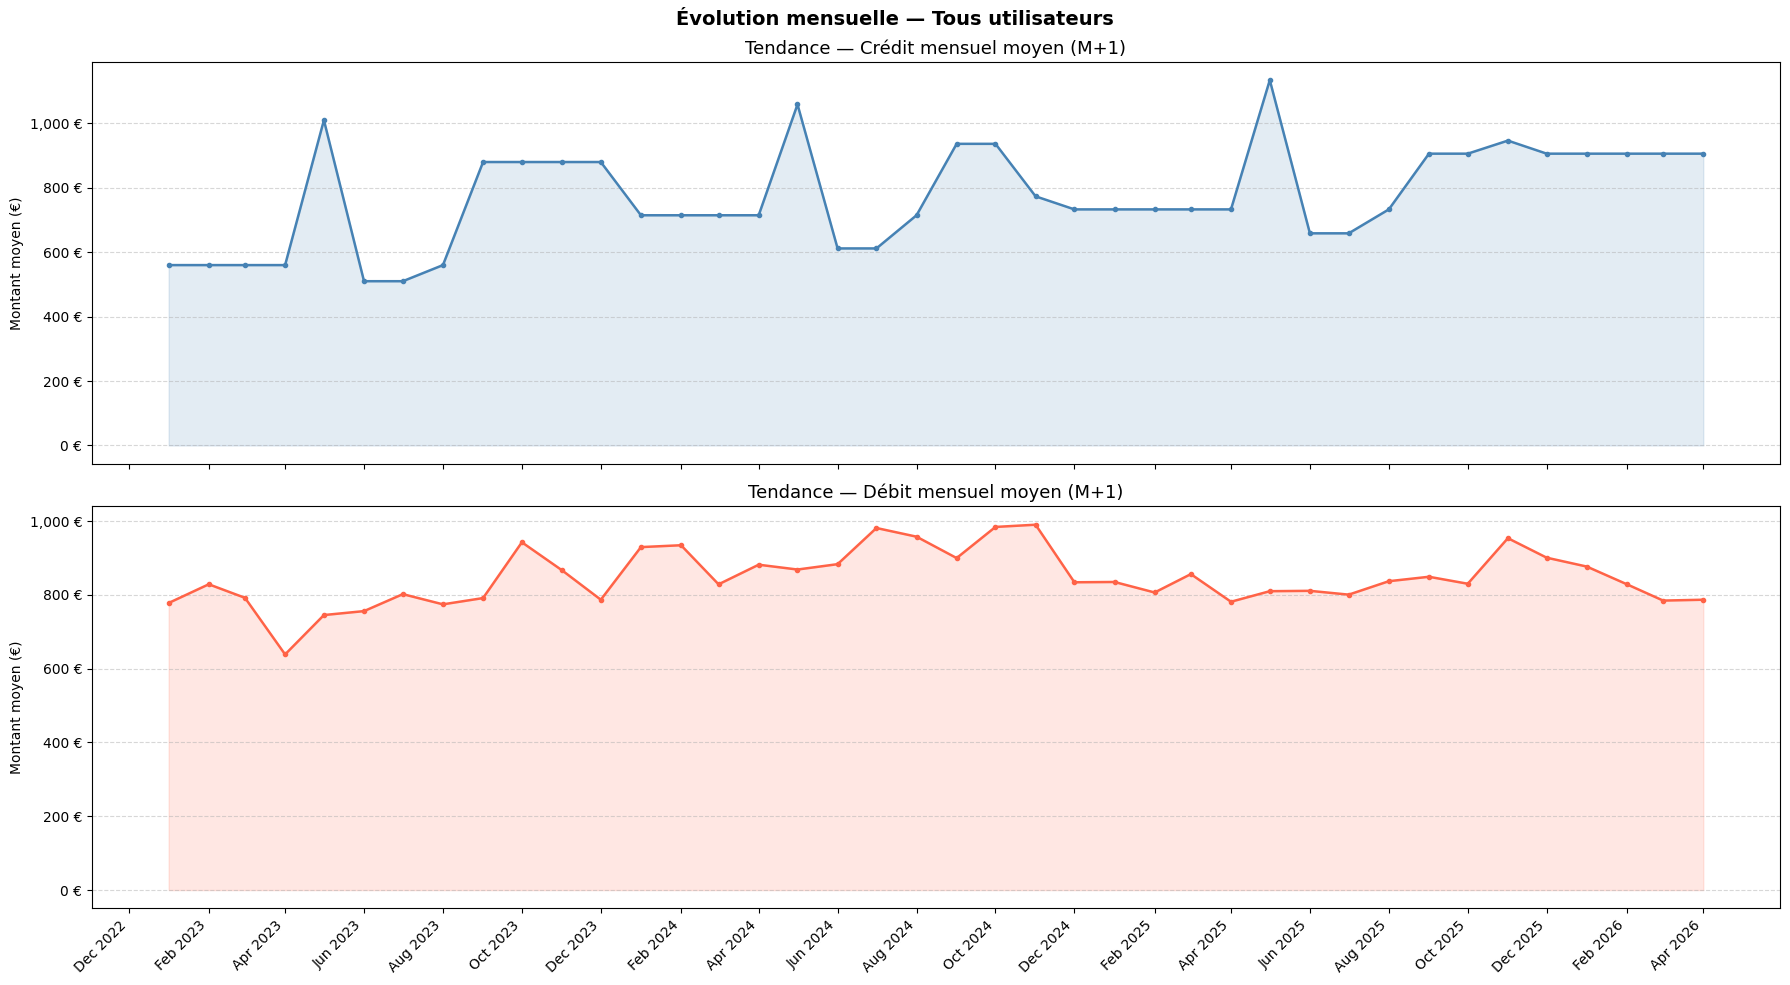

Mois par user :
 count    37.000000
mean     23.243243
std       6.348252
min      18.000000
25%      18.000000
50%      18.000000
75%      28.000000
max      40.000000
Name: mois_annee, dtype: float64
→ SEQ_LEN=3  |  MIN_MOIS=6
Train : 674 lignes | Test : 186 lignes


In [4]:

# ============================================================
# VISUALISATION TENDANCE
# ============================================================

tendance = (
    monthly.groupby('mois_annee')[['cible_credit_mois_suivant','cible_debit_mois_suivant']]
    .mean().reset_index().sort_values('mois_annee')
)
fig, axes = plt.subplots(2, 1, figsize=(18, 10), sharex=True)
for ax, col, color, titre in [
    (axes[0], 'cible_credit_mois_suivant', 'steelblue', 'Crédit'),
    (axes[1], 'cible_debit_mois_suivant',  'tomato',    'Débit'),
]:
    ax.plot(tendance['mois_annee'], tendance[col], color=color, linewidth=1.8, marker='o', markersize=3)
    ax.fill_between(tendance['mois_annee'], tendance[col], alpha=0.15, color=color)
    ax.set_title(f'Tendance — {titre} mensuel moyen (M+1)', fontsize=13)
    ax.set_ylabel('Montant moyen (€)')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:,.0f} €'))
    ax.grid(axis='y', linestyle='--', alpha=0.5)
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))
plt.xticks(rotation=45, ha='right')
plt.suptitle('Évolution mensuelle — Tous utilisateurs', fontsize=14, fontweight='bold')
plt.tight_layout(); plt.show()


# ============================================================
# SPLIT + FEATURES  (commun crédit & débit)
# ============================================================

features_list = [
    'total_credit', 'total_debit',
    'credit_lag1',  'debit_lag1',
    'moyenne_credit_3m', 'moyenne_debit_3m',
    'std_credit_3m', 'std_debit_3m',
    'solde_lag1', 'tendance_credit', 'tendance_debit',
    'nb_transactions',
]

# [FIX 3] SEQ_LEN adaptatif
mois_par_user = base_principale4.groupby('user_id')['mois_annee'].nunique()
print("Mois par user :\n", mois_par_user.describe())
mediane_mois  = int(mois_par_user.median())
SEQ_LEN       = max(2, min(3, mediane_mois // 2))
MIN_MOIS      = SEQ_LEN + 3
print(f"→ SEQ_LEN={SEQ_LEN}  |  MIN_MOIS={MIN_MOIS}")

users_ok       = mois_par_user[mois_par_user >= MIN_MOIS].index
base_filtree   = base_principale4[base_principale4['user_id'].isin(users_ok)].copy()

def train_test_split_par_user(df, ratio=0.8):
    train_list, test_list = [], []
    for uid, grp in df.groupby('user_id'):
        grp = grp.sort_values('mois_annee')
        n   = len(grp)
        cut = int(n * ratio)
        if cut < SEQ_LEN or n - cut < 2:
            continue
        train_list.append(grp.iloc[:cut])
        test_list.append(grp.iloc[cut:])
    return pd.concat(train_list), pd.concat(test_list)

train_df, test_df = train_test_split_par_user(base_filtree, ratio=0.8)
print(f"Train : {len(train_df)} lignes | Test : {len(test_df)} lignes")


def build_sequences(df, feature_cols, target_col, seq_len):
    X_seqs, y_seqs = [], []
    for uid, grp in df.groupby('user_id'):
        grp     = grp.sort_values('mois_annee')
        feats   = grp[feature_cols].values
        targets = grp[target_col].values
        for i in range(seq_len, len(feats)):
            X_seqs.append(feats[i - seq_len:i])
            y_seqs.append(targets[i])
    return np.array(X_seqs), np.array(y_seqs)


def plot_resultats(history, y_reel, y_predit, titre_modele, label_type='Crédit'):
    """[FIX 7] label_type dynamique : 'Crédit' ou 'Débit'"""
    fig, axes = plt.subplots(1, 2, figsize=(18, 5))
    axes[0].plot(history.history['loss'],     label='Train Loss')
    axes[0].plot(history.history['val_loss'], label='Val Loss')
    axes[0].set_title(f"Courbe d'apprentissage — {titre_modele}")
    axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('MSE'); axes[0].legend()

    x = np.arange(len(y_reel))
    axes[1].plot(x, y_reel,   label=f'{label_type} Réel (€)',   linewidth=1.5, color='steelblue')
    axes[1].plot(x, y_predit, label=f'{label_type} Prédit (€)', linewidth=1.5, color='tomato', linestyle='--')
    axes[1].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f'{v:,.0f} €'))
    axes[1].set_title(f'{titre_modele} — Prédictions vs Réalité')
    axes[1].set_xlabel(f'Échantillon (n={len(y_reel)})'); axes[1].set_ylabel(f'{label_type} mensuel (€)')
    axes[1].legend()
    plt.tight_layout(); plt.show()

    # Scatter
    r2 = r2_score(y_reel, y_predit)
    plt.figure(figsize=(6, 6))
    plt.scatter(y_reel, y_predit, alpha=0.4, s=15, color='steelblue')
    lim = [min(y_reel.min(), y_predit.min()), max(y_reel.max(), y_predit.max())]
    plt.plot(lim, lim, 'r--', linewidth=1, label='Prédiction parfaite')
    plt.xlabel(f'{label_type} Réel (€)'); plt.ylabel(f'{label_type} Prédit (€)')
    plt.title(f'Scatter — {titre_modele}  (R²={r2:.3f})')
    plt.legend(); plt.tight_layout(); plt.show()


# [FIX 5] predict_future_user sans feature_scaler inutile
def predict_future_user(model, user_id, test_df_scaled, features_list,
                        target_scaler_fn, seq_len, n_steps=3,
                        idx_principal=None, idx_lag=None, idx_moy=None):
    user_data = (
        test_df_scaled[test_df_scaled['user_id'] == user_id]
        .sort_values('mois_annee')
    )
    if len(user_data) < seq_len:
        print(f"[WARN] User {user_id} : {len(user_data)} mois < {seq_len} requis.")
        return None, None

    current_sequence    = user_data[features_list].values[-seq_len:].copy()
    future_preds_scaled = []

    for _ in range(n_steps):
        pred_scaled = model.predict(
            current_sequence.reshape(1, seq_len, len(features_list)), verbose=0
        )[0, 0]
        future_preds_scaled.append(pred_scaled)
        new_row = current_sequence[-1].copy()
        if idx_lag is not None:
            new_row[idx_lag]       = current_sequence[-1, idx_principal]
        if idx_principal is not None:
            new_row[idx_principal] = pred_scaled
        if idx_moy is not None:
            last_3 = np.append(current_sequence[-2:, idx_principal], pred_scaled)
            new_row[idx_moy]       = last_3.mean()
        current_sequence = np.vstack([current_sequence[1:], new_row])

    future_preds = target_scaler_fn(np.array(future_preds_scaled))
    future_dates = pd.date_range(
        start=user_data['mois_annee'].max() + pd.DateOffset(months=1),
        periods=n_steps, freq='MS'
    )
    return future_dates, future_preds


# [FIX 4] predict_all_users décommenté, signature unifiée
def predict_all_users(model, test_df_scaled, test_df, features_list,
                      target_scaler_fn, seq_len, n_steps=3,
                      col_predit='credit_predit', col_reel='total_credit',
                      idx_principal=None, idx_lag=None, idx_moy=None):
    results = []
    for uid in test_df['user_id'].unique():
        dates, preds = predict_future_user(
            model, uid, test_df_scaled, features_list,
            target_scaler_fn, seq_len, n_steps,
            idx_principal, idx_lag, idx_moy
        )
        if preds is not None:
            for d, p in zip(dates, preds):
                results.append({'user_id': uid, 'mois': d, col_predit: round(p, 2)})

    df = pd.DataFrame(results)
    actuals = (
        test_df[['user_id', 'mois_annee', col_reel]]
        .rename(columns={'mois_annee': 'mois', col_reel: col_reel + '_reel'})
    )
    actuals['mois'] = pd.to_datetime(actuals['mois'])
    df = df.merge(actuals, on=['user_id', 'mois'], how='left')
    reel_col = col_reel + '_reel'
    df['ecart_euros'] = (df[col_predit] - df[reel_col]).round(2)
    df['ecart_pct']   = ((df['ecart_euros'] / df[reel_col].replace(0, np.nan)) * 100).round(1)
    return df

In [5]:

# ============================================================
# MODÈLES CLASSIQUES  (Random Forest + XGBoost)
# ============================================================

# Scaling features pour RF/XGB (sans scaling cible)
X_train = train_df[features_list]
y_train_credit = train_df['cible_credit_mois_suivant']
X_test  = test_df[features_list]
y_test_credit  = test_df['cible_credit_mois_suivant']

classic_scaler = StandardScaler()
X_train_scaled = classic_scaler.fit_transform(X_train)
X_test_scaled  = classic_scaler.transform(X_test)

# Random Forest
rf_model = RandomForestRegressor(n_estimators=500, max_depth=4, random_state=42)
rf_model.fit(X_train_scaled, y_train_credit)
y_pred_rf = rf_model.predict(X_test_scaled)
print(f"\n--- Random Forest (Crédit) ---")
print(f"MAE : {mean_absolute_error(y_test_credit, y_pred_rf):.2f} €")
print(f"R²  : {r2_score(y_test_credit, y_pred_rf):.4f}")

# XGBoost
split_val     = int(len(X_train_scaled) * 0.9)
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror', n_estimators=500, learning_rate=0.05,
    max_depth=5, subsample=0.8, colsample_bytree=0.8,
    min_child_weight=5, random_state=42, early_stopping_rounds=30
)
xgb_model.fit(
    X_train_scaled[:split_val], y_train_credit.iloc[:split_val],
    eval_set=[(X_train_scaled[split_val:], y_train_credit.iloc[split_val:])],
    verbose=50
)
y_pred_xgb = xgb_model.predict(X_test_scaled)
print(f"\n--- XGBoost (Crédit) ---")
print(f"MAE : {mean_absolute_error(y_test_credit, y_pred_xgb):.2f} €")
print(f"R²  : {r2_score(y_test_credit, y_pred_xgb):.4f}")


--- Random Forest (Crédit) ---
MAE : 61.92 €
R²  : 0.8113
[0]	validation_0-rmse:691.68642
[50]	validation_0-rmse:620.11900
[100]	validation_0-rmse:604.03899
[150]	validation_0-rmse:595.59130
[200]	validation_0-rmse:588.44822
[250]	validation_0-rmse:587.95390
[300]	validation_0-rmse:587.07635
[350]	validation_0-rmse:585.54801
[364]	validation_0-rmse:585.57249

--- XGBoost (Crédit) ---
MAE : 121.66 €
R²  : -0.1420



Séquences crédit — Train:(563, 3, 12) | Test:(75, 3, 12)


c:\Users\jessi\Desktop\Mes cours Ynov\Ydays et autres\Projets_ecole\deep_venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 38ms/step - loss: 0.3946 - mean_absolute_error: 0.5113 - val_loss: 4.1655 - val_mean_absolute_error: 1.6263
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2983 - mean_absolute_error: 0.3956 - val_loss: 3.2629 - val_mean_absolute_error: 1.3820
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2727 - mean_absolute_error: 0.3686 - val_loss: 3.1193 - val_mean_absolute_error: 1.3389
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2524 - mean_absolute_error: 0.3499 - val_loss: 3.0873 - val_mean_absolute_error: 1.3238
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2330 - mean_absolute_error: 0.3236 - val_loss: 3.1695 - val_mean_absolute_error: 1.3370
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2314 - mean_absolute_error: 0.3286 - val_loss: 3.2429 - val_mean_absolute_error: 1.3486
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.2199 - mean_absolute_error: 0.3110 - val_lo

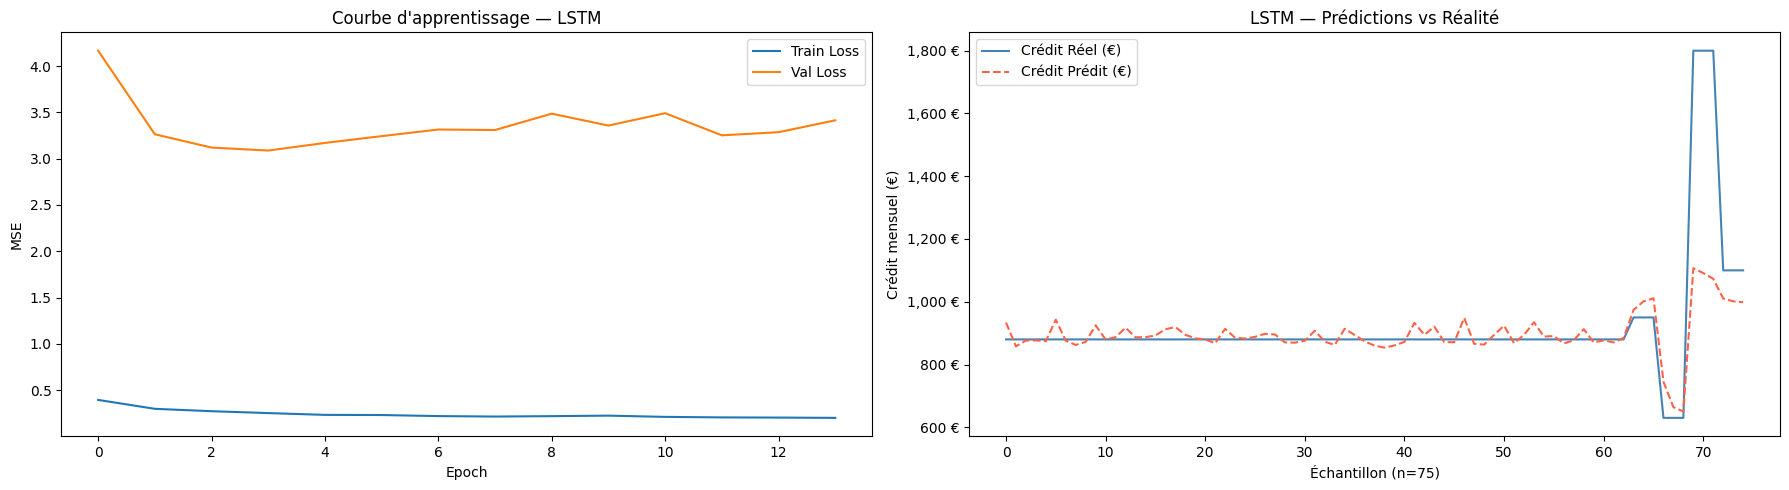

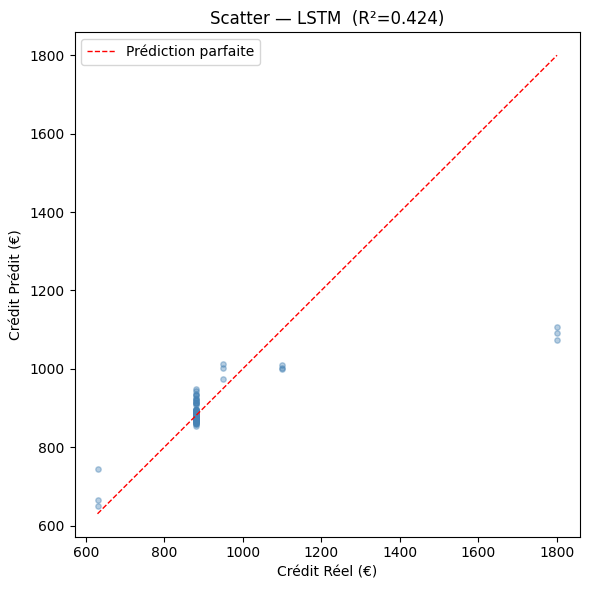

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 3, 12)     │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1d (Conv1D)     │ (None, 3, 64)     │      2,368 │ input_layer_1[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_2 (LSTM)       │ (None, 3, 50)     │     23,000 │ conv1d[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_1 (Dense)     │ (None, 3, 64)     │      3,264 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_2 (Dense)     │ (None, 3, 64)     │      3,264 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_3 (Dense)     │ (None, 3, 64)     │      3,264 │ lstm_2[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ attention           │ (None, 3, 64)     │          0 │ dense_1[0][0],    │
│ (Attention)         │                   │            │ dense_2[0][0],    │
│                     │                   │            │ dense_3[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ flatten (Flatten)   │ (None, 192)       │          0 │ attention[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_2 (Dropout) │ (None, 192)       │          0 │ flatten[0][0]     │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_4 (Dense)     │ (None, 50)        │      9,650 │ dropout_2[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_5 (Dense)     │ (None, 1)         │         51 │ dense_4[0][0]     │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 44,861 (175.24 KB)

 Trainable params: 44,861 (175.24 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 4s 33ms/step - loss: 0.3491 - mean_absolute_error: 0.4531 - val_loss: 2.0101 - val_mean_absolute_error: 1.0732
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2643 - mean_absolute_error: 0.3554 - val_loss: 2.4767 - val_mean_absolute_error: 1.2098
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2282 - mean_absolute_error: 0.3062 - val_loss: 2.3980 - val_mean_absolute_error: 1.1871
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2012 - mean_absolute_error: 0.2858 - val_loss: 2.8415 - val_mean_absolute_error: 1.2960
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2023 - mean_absolute_error: 0.2745 - val_loss: 2.8354 - val_mean_absolute_error: 1.2838
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1871 - mean_absolute_error: 0.2578 - val_loss: 2.8077 - val_mean_absolute_error: 1.2900
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.1789 - mean_absolute_error: 0.2527 - val_l

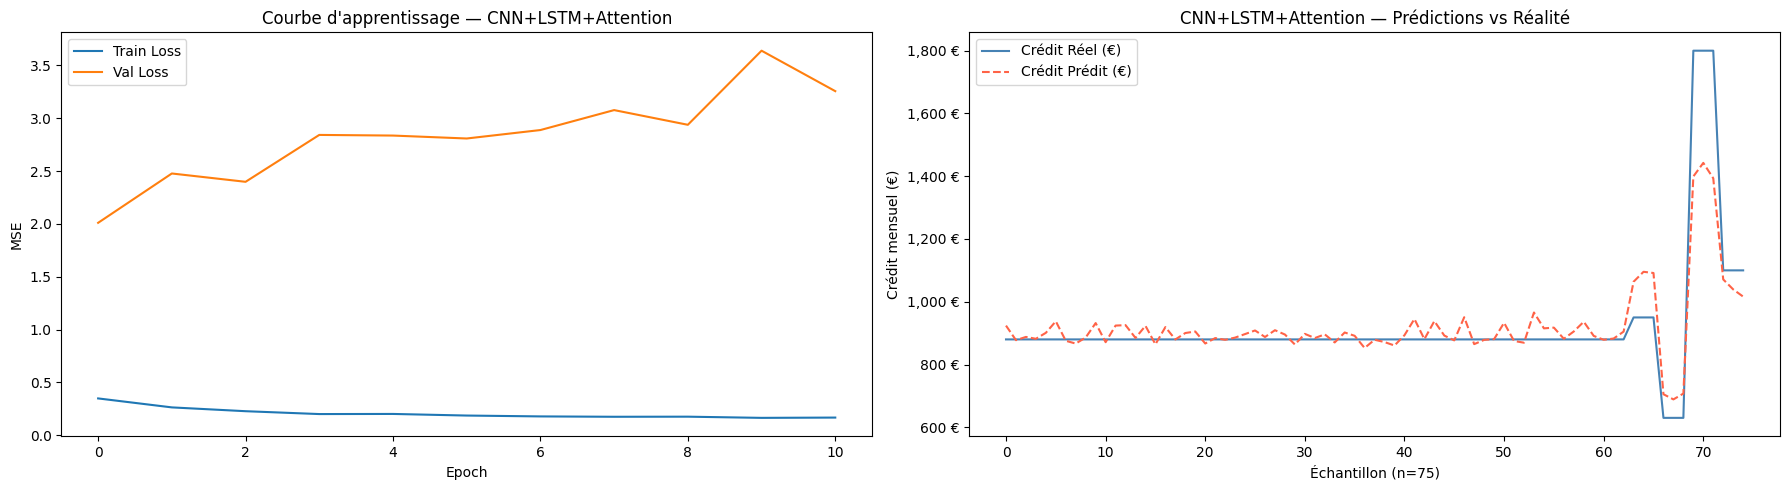

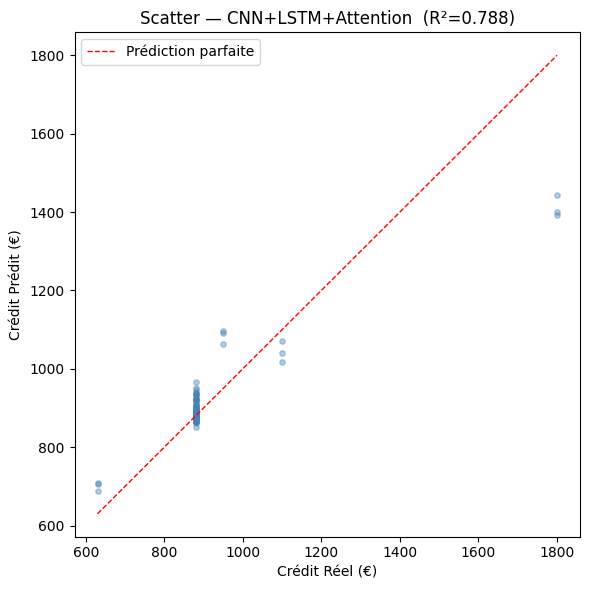


Prédictions crédit — 37 utilisateurs
 user_id       mois  credit_predit  total_credit_reel  ecart_euros  ecart_pct
       1 2026-05-01     876.270020                NaN          NaN        NaN
       1 2026-06-01     935.179993                NaN          NaN        NaN
       1 2026-07-01     904.890015                NaN          NaN        NaN


In [6]:

# ============================================================
# PIPELINE CRÉDIT — LSTM + CNN+LSTM+ATTENTION
# ============================================================

# [FIX 1] Scalers séparés features / cible crédit
feature_scaler        = StandardScaler()
target_scaler_credit  = StandardScaler()

train_df_scaled_credit = train_df.copy()
test_df_scaled_credit  = test_df.copy()
train_df_scaled_credit[features_list]                  = feature_scaler.fit_transform(train_df[features_list])
test_df_scaled_credit[features_list]                   = feature_scaler.transform(test_df[features_list])
train_df_scaled_credit['cible_credit_mois_suivant']    = target_scaler_credit.fit_transform(train_df[['cible_credit_mois_suivant']])
test_df_scaled_credit['cible_credit_mois_suivant']     = target_scaler_credit.transform(test_df[['cible_credit_mois_suivant']])

X_train_3D_credit, y_train_credit_seq = build_sequences(train_df_scaled_credit, features_list, 'cible_credit_mois_suivant', SEQ_LEN)
X_test_3D_credit,  y_test_credit_seq  = build_sequences(test_df_scaled_credit,  features_list, 'cible_credit_mois_suivant', SEQ_LEN)
print(f"\nSéquences crédit — Train:{X_train_3D_credit.shape} | Test:{X_test_3D_credit.shape}")

def inv_credit(arr): return target_scaler_credit.inverse_transform(np.array(arr).flatten().reshape(-1,1)).flatten()

y_test_credit_euros = inv_credit(y_test_credit_seq)

# Patch Attention (score_mode=np.dot bug)
_original_init = kl.Attention.__init__
def _patched_init(self, score_mode="dot", **kwargs):
    if callable(score_mode): score_mode = "dot"
    _original_init(self, score_mode=score_mode, **kwargs)
kl.Attention.__init__ = _patched_init

def build_cnn_lstm_att(seq_len, n_feat):
    inp   = Input(shape=(seq_len, n_feat))
    x     = Conv1D(64, kernel_size=3, activation='relu', padding='same')(inp)
    x     = LSTM(50, return_sequences=True)(x)
    q,v,k = Dense(64)(x), Dense(64)(x), Dense(64)(x)
    x     = KerasAttention()([q, v, k])
    x     = Flatten()(x)
    x     = Dropout(0.2)(x)
    x     = Dense(50, activation='relu')(x)
    out   = Dense(1)(x)
    m     = Model(inputs=inp, outputs=out)
    m.compile(optimizer='adam', loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
    return m

# LSTM Crédit
credit_model_lstm = Sequential([
    LSTM(64, activation='tanh', input_shape=(SEQ_LEN, len(features_list)), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
credit_model_lstm.compile(optimizer='adam', loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
history_lstm_credit = credit_model_lstm.fit(
    X_train_3D_credit, y_train_credit_seq, epochs=100, batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], verbose=1
)
y_pred_lstm_credit = inv_credit(credit_model_lstm.predict(X_test_3D_credit).flatten())
print(f"\n--- LSTM Crédit ---  MAE:{mean_absolute_error(y_test_credit_euros,y_pred_lstm_credit):.2f}€  R²:{r2_score(y_test_credit_euros,y_pred_lstm_credit):.4f}")
plot_resultats(history_lstm_credit, y_test_credit_euros, y_pred_lstm_credit, "LSTM", "Crédit")

# CNN+LSTM+Attention Crédit
credit_cnn_lstm_att_model = build_cnn_lstm_att(SEQ_LEN, len(features_list))
credit_cnn_lstm_att_model.summary()
history_cnn_credit = credit_cnn_lstm_att_model.fit(
    X_train_3D_credit, y_train_credit_seq, epochs=100, batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], verbose=1
)
y_pred_cnn_credit = inv_credit(credit_cnn_lstm_att_model.predict(X_test_3D_credit).flatten())
print(f"\n--- CNN+LSTM+Att Crédit ---  MAE:{mean_absolute_error(y_test_credit_euros,y_pred_cnn_credit):.2f}€  R²:{r2_score(y_test_credit_euros,y_pred_cnn_credit):.4f}")
plot_resultats(history_cnn_credit, y_test_credit_euros, y_pred_cnn_credit, "CNN+LSTM+Attention", "Crédit")

# Prédictions futures crédit
idx_c = features_list.index('total_credit')
idx_cl = features_list.index('credit_lag1')
idx_cm = features_list.index('moyenne_credit_3m')

N_MOIS_FUTURS   = 3
EXEMPLE_USER_ID = test_df['user_id'].iloc[0]

df_pred_credit = predict_all_users(
    credit_cnn_lstm_att_model, test_df_scaled_credit, test_df,
    features_list, inv_credit, SEQ_LEN, N_MOIS_FUTURS,
    col_predit='credit_predit', col_reel='total_credit',
    idx_principal=idx_c, idx_lag=idx_cl, idx_moy=idx_cm
)
print(f"\nPrédictions crédit — {df_pred_credit['user_id'].nunique()} utilisateurs")
print(df_pred_credit[df_pred_credit['user_id'] == EXEMPLE_USER_ID].to_string(index=False))


Séquences débit — Train:(563, 3, 12) | Test:(75, 3, 12)
Epoch 1/100


c:\Users\jessi\Desktop\Mes cours Ynov\Ydays et autres\Projets_ecole\deep_venv\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


16/16 ━━━━━━━━━━━━━━━━━━━━ 6s 43ms/step - loss: 0.3358 - mean_absolute_error: 0.4353 - val_loss: 5.3221 - val_mean_absolute_error: 1.3936
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.3132 - mean_absolute_error: 0.4129 - val_loss: 4.8840 - val_mean_absolute_error: 1.3111
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.3056 - mean_absolute_error: 0.4086 - val_loss: 4.2565 - val_mean_absolute_error: 1.1965
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2986 - mean_absolute_error: 0.4090 - val_loss: 3.9820 - val_mean_absolute_error: 1.1484
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.2936 - mean_absolute_error: 0.4069 - val_loss: 3.3063 - val_mean_absolute_error: 1.0180
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - loss: 0.2956 - mean_absolute_error: 0.4110 - val_loss: 3.3492 - val_mean_absolute_error: 1.0321
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.2873 - mean_absolute_error: 0.4041 - val_loss: 3.04

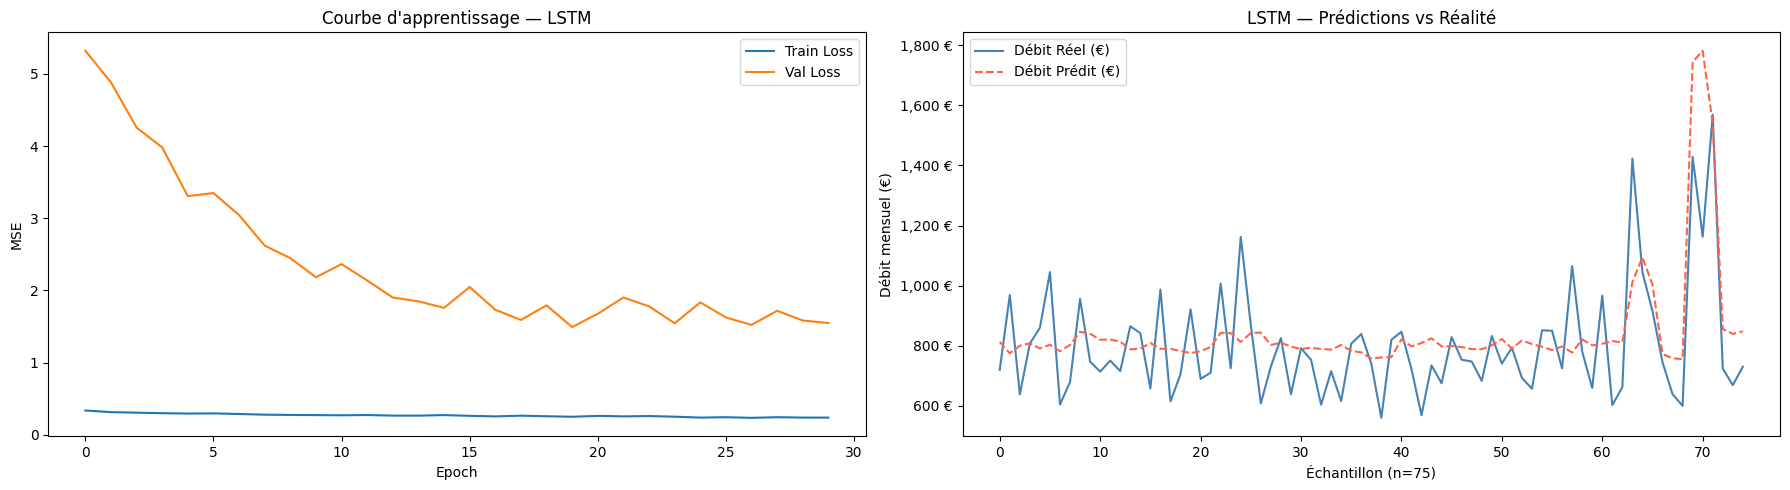

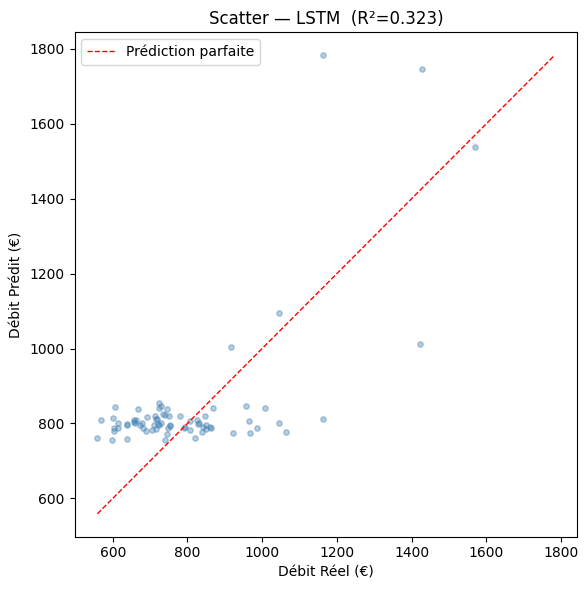

Epoch 1/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 5s 42ms/step - loss: 0.3327 - mean_absolute_error: 0.4220 - val_loss: 4.9689 - val_mean_absolute_error: 1.3396
Epoch 2/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.2982 - mean_absolute_error: 0.4093 - val_loss: 4.0112 - val_mean_absolute_error: 1.1477
Epoch 3/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2908 - mean_absolute_error: 0.4123 - val_loss: 2.9690 - val_mean_absolute_error: 0.9436
Epoch 4/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.2891 - mean_absolute_error: 0.4006 - val_loss: 3.0835 - val_mean_absolute_error: 0.9999
Epoch 5/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2701 - mean_absolute_error: 0.4060 - val_loss: 2.2929 - val_mean_absolute_error: 0.8206
Epoch 6/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.2529 - mean_absolute_error: 0.3854 - val_loss: 1.6220 - val_mean_absolute_error: 0.7290
Epoch 7/100
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.2560 - mean_absolute_error: 0.3854 - va

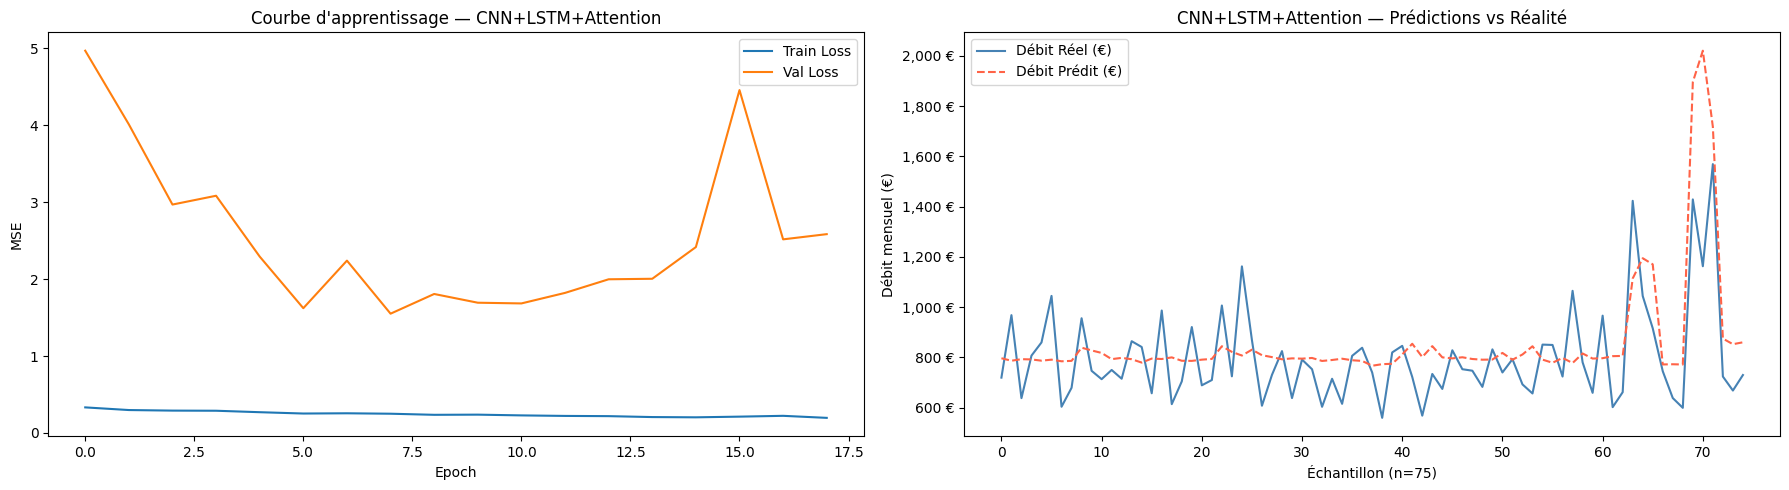

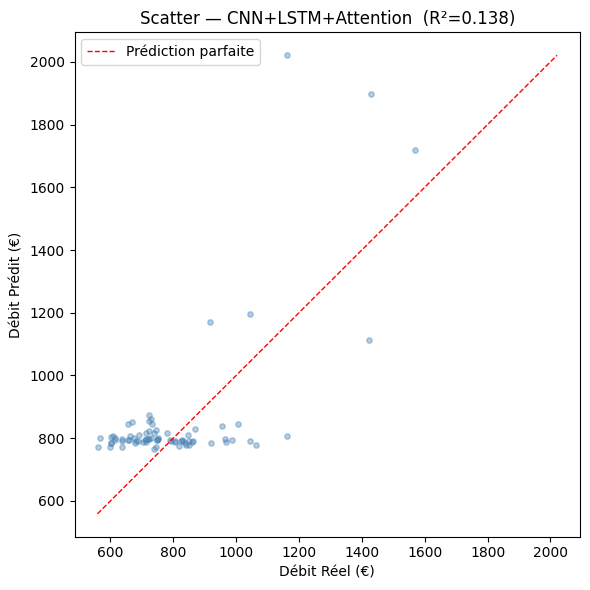


Prédictions débit — 37 utilisateurs
 user_id       mois  debit_predit  total_debit_reel  ecart_euros  ecart_pct
       1 2026-05-01    789.909973               NaN          NaN        NaN
       1 2026-06-01    778.299988               NaN          NaN        NaN
       1 2026-07-01    789.500000               NaN          NaN        NaN


In [7]:

# ============================================================
# PIPELINE DÉBIT — LSTM + CNN+LSTM+ATTENTION
# ============================================================

# [FIX 2] Scaler dédié pour la cible débit
feature_scaler_debit = StandardScaler()
target_scaler_debit  = StandardScaler()

train_df_scaled_debit = train_df.copy()
test_df_scaled_debit  = test_df.copy()
train_df_scaled_debit[features_list]                 = feature_scaler_debit.fit_transform(train_df[features_list])
test_df_scaled_debit[features_list]                  = feature_scaler_debit.transform(test_df[features_list])
train_df_scaled_debit['cible_debit_mois_suivant']    = target_scaler_debit.fit_transform(train_df[['cible_debit_mois_suivant']])
test_df_scaled_debit['cible_debit_mois_suivant']     = target_scaler_debit.transform(test_df[['cible_debit_mois_suivant']])

X_train_3D_debit, y_train_debit_seq = build_sequences(train_df_scaled_debit, features_list, 'cible_debit_mois_suivant', SEQ_LEN)
X_test_3D_debit,  y_test_debit_seq  = build_sequences(test_df_scaled_debit,  features_list, 'cible_debit_mois_suivant', SEQ_LEN)
print(f"\nSéquences débit — Train:{X_train_3D_debit.shape} | Test:{X_test_3D_debit.shape}")

def inv_debit(arr): return target_scaler_debit.inverse_transform(np.array(arr).flatten().reshape(-1,1)).flatten()

y_test_debit_euros = inv_debit(y_test_debit_seq)

# LSTM Débit
debit_model_lstm = Sequential([
    LSTM(64, activation='tanh', input_shape=(SEQ_LEN, len(features_list)), return_sequences=True),
    Dropout(0.2),
    LSTM(32, activation='tanh', return_sequences=False),
    Dropout(0.2),
    Dense(1)
])
debit_model_lstm.compile(optimizer='adam', loss=MeanSquaredError(), metrics=[MeanAbsoluteError()])
history_lstm_debit = debit_model_lstm.fit(
    X_train_3D_debit, y_train_debit_seq, epochs=100, batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], verbose=1
)
y_pred_lstm_debit = inv_debit(debit_model_lstm.predict(X_test_3D_debit).flatten())
print(f"\n--- LSTM Débit ---  MAE:{mean_absolute_error(y_test_debit_euros,y_pred_lstm_debit):.2f}€  R²:{r2_score(y_test_debit_euros,y_pred_lstm_debit):.4f}")
plot_resultats(history_lstm_debit, y_test_debit_euros, y_pred_lstm_debit, "LSTM", "Débit")

# CNN+LSTM+Attention Débit
debit_cnn_lstm_att_model = build_cnn_lstm_att(SEQ_LEN, len(features_list))  # [FIX 6] plus de doublon
history_cnn_debit = debit_cnn_lstm_att_model.fit(
    X_train_3D_debit, y_train_debit_seq, epochs=100, batch_size=32,
    validation_split=0.1,
    callbacks=[EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)], verbose=1
)
y_pred_cnn_debit = inv_debit(debit_cnn_lstm_att_model.predict(X_test_3D_debit).flatten())
print(f"\n--- CNN+LSTM+Att Débit ---  MAE:{mean_absolute_error(y_test_debit_euros,y_pred_cnn_debit):.2f}€  R²:{r2_score(y_test_debit_euros,y_pred_cnn_debit):.4f}")
plot_resultats(history_cnn_debit, y_test_debit_euros, y_pred_cnn_debit, "CNN+LSTM+Attention", "Débit")

# Prédictions futures débit
idx_d  = features_list.index('total_debit')
idx_dl = features_list.index('debit_lag1')
idx_dm = features_list.index('moyenne_debit_3m')

df_pred_debit = predict_all_users(
    debit_cnn_lstm_att_model, test_df_scaled_debit, test_df,
    features_list, inv_debit, SEQ_LEN, N_MOIS_FUTURS,
    col_predit='debit_predit', col_reel='total_debit',
    idx_principal=idx_d, idx_lag=idx_dl, idx_moy=idx_dm
)
print(f"\nPrédictions débit — {df_pred_debit['user_id'].nunique()} utilisateurs")
print(df_pred_debit[df_pred_debit['user_id'] == EXEMPLE_USER_ID].to_string(index=False))

kl.Attention.__init__ = _original_init  # restauration patch

In [8]:

# ============================================================
# [FIX 8] EXPORT — après entraînement des deux modèles
# ============================================================

SAVE_DIR = "models_smartsave"
os.makedirs(SAVE_DIR, exist_ok=True)

for nom, modele in [
    ("credit_cnn_lstm_attention", credit_cnn_lstm_att_model),
    ("debit_cnn_lstm_attention",  debit_cnn_lstm_att_model),
    ("credit_model_lstm",         credit_model_lstm),
    ("debit_model_lstm",          debit_model_lstm),
]:
    modele.save(os.path.join(SAVE_DIR, f"{nom}.h5"))
    modele.save(os.path.join(SAVE_DIR, f"{nom}.keras"))
    print(f"✅ {nom} sauvegardé")

with open(os.path.join(SAVE_DIR, "scalers_smartsave.pkl"), "wb") as f:
    pickle.dump({
        "feature_scaler":       feature_scaler,
        "feature_scaler_debit": feature_scaler_debit,
        "target_scaler_credit": target_scaler_credit,
        "target_scaler_debit":  target_scaler_debit,
        "features_list":        features_list,
        "SEQ_LEN":              SEQ_LEN,
    }, f)
print("✅ Scalers sauvegardés")

✅ credit_cnn_lstm_attention sauvegardé
✅ debit_cnn_lstm_attention sauvegardé
✅ credit_model_lstm sauvegardé


✅ debit_model_lstm sauvegardé
✅ Scalers sauvegardés
